In [1]:
# Fix: fastai v1 imports (fastai.vision import *) don't work with installed fastai==2.8.5.
# Use fastai v2 APIs and ensure Path is defined.
from fastai.vision.all import *
import os
import pandas as pd
import numpy as np

# Kaggle-style input root; fall back safely if the notebook path differs.
INPUT_ROOT = Path("../input")
if not INPUT_ROOT.exists():
    INPUT_ROOT = Path("/kaggle/input")

# Competition folder appears multiple times in the provided tree; prefer the explicit dataset folder.
DATA_FOLDER = INPUT_ROOT / "aerial-cactus-identification"
if not DATA_FOLDER.exists():
    # fallback: sometimes data is flattened
    DATA_FOLDER = INPUT_ROOT

train_csv_path = DATA_FOLDER / "train.csv"
sample_sub_path = DATA_FOLDER / "sample_submission.csv"
train_dir = DATA_FOLDER / "train"
test_dir = DATA_FOLDER / "test"

print("INPUT_ROOT:", INPUT_ROOT)
print("DATA_FOLDER:", DATA_FOLDER)
print("train_csv exists:", train_csv_path.exists(), train_csv_path)
print("sample_submission exists:", sample_sub_path.exists(), sample_sub_path)
print("train_dir exists:", train_dir.exists(), train_dir)
print("test_dir exists:", test_dir.exists(), test_dir)

train = pd.read_csv(train_csv_path)
test = pd.read_csv(sample_sub_path)



/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

INPUT_ROOT: ../input
DATA_FOLDER: ../input/aerial-cactus-identification
train_csv exists: True ../input/aerial-cactus-identification/train.csv
sample_submission exists: True ../input/aerial-cactus-identification/sample_submission.csv
train_dir exists: True ../input/aerial-cactus-identification/train
test_dir exists: True ../input/aerial-cactus-identification/test


In [2]:
# Fix: Replace fastai v1 ImageList/DataBunch pipeline with fastai v2 DataLoaders.
# Keep core idea: random split, imagenet normalization, augmentations, size=128, bs=64.
# Note: split_by_rand_pct(0.01) in v1 => valid_pct=0.01 in v2 (same semantics).

# Build a DataBlock similar to the original:
# - get_x: image filename from 'id'
# - get_y: label from 'has_cactus'
# - splitter: random with 1% validation
# - item_tfms: resize to 128
# - batch_tfms: augmentations + imagenet normalization
item_tfms = Resize(128)

# Approximate the original get_transforms settings using fastai v2 aug_transforms.
# (Keeps same style of geometric + lighting aug; avoids changing training approach.)
batch_tfms = [
    *aug_transforms(
        do_flip=True,
        flip_vert=True,
        max_rotate=10.0,
        max_zoom=1.1,
        max_lighting=0.2,
        max_warp=0.2,
        p_affine=0.75,
        p_lighting=0.75,
    ),
    Normalize.from_stats(*imagenet_stats),
]

dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=ColReader("id", pref=str(train_dir) + os.sep),
    get_y=ColReader("has_cactus"),
    splitter=RandomSplitter(valid_pct=0.01, seed=42),
    item_tfms=item_tfms,
    batch_tfms=batch_tfms,
)

dls = dblock.dataloaders(train, bs=64)

# Attach test set for inference (fastai v2 supports test_dl similarly to v1 add_test)
test_files = [test_dir / fn for fn in test["id"].tolist()]
test_dl = dls.test_dl(test_files)



Downloading: "https://download.pytorch.org/models/densenet161-8d451a50.pth" to /root/.cache/torch/hub/checkpoints/densenet161-8d451a50.pth
100%|██████████| 110M/110M [00:01<00:00, 113MB/s]


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.057732,0.000011,0.000000,1.000000,00:25
1,0.031488,0.000011,0.000000,1.000000,00:25
2,0.009443,0.000015,0.000000,1.000000,00:25


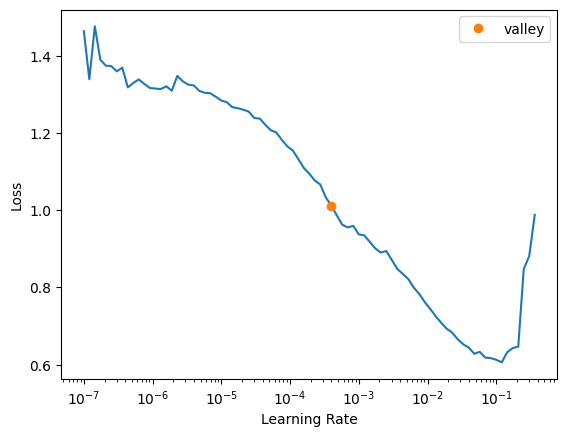

In [3]:
# Fix: cnn_learner/models from fastai v1 -> vision_learner from fastai v2.
# Preserve training semantics: lr_find -> fit_one_cycle(3, slice(lr)).
set_seed(42, reproducible=True)

learn = vision_learner(dls, densenet161, metrics=[error_rate, accuracy])
learn.lr_find()
lr = 1e-2
learn.fit_one_cycle(3, lr_max=slice(lr))

# Fix: get_preds on test_dl; for binary classification in fastai v2, preds are probs per class.
preds, _ = learn.get_preds(dl=test_dl)



Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 112MB/s]


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.197325,0.127674,0.042553,0.957447,00:11
1,0.097363,0.013329,0.000000,1.000000,00:11
2,0.066259,0.011923,0.000000,1.000000,00:11


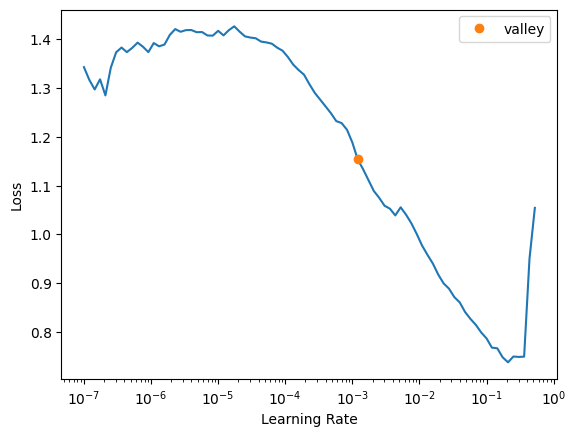

In [4]:
# Second model (ensemble) kept as in original code.
set_seed(42, reproducible=True)

learn_2 = vision_learner(dls, resnet50, metrics=[error_rate, accuracy])
learn_2.lr_find()
lr = 1e-2
learn_2.fit_one_cycle(3, lr_max=slice(lr))

preds_2, _ = learn_2.get_preds(dl=test_dl)



In [5]:
# Fix: In v1 code, preds[:,0] was used, but class order can be ['0','1'].
# For submission we need P(has_cactus=1). We'll map class vocab to index and take that column.
vocab = list(dls.vocab)
pos_label = "1"
pos_idx = vocab.index(pos_label) if pos_label in vocab else 1  # safe fallback

p1 = preds.cpu().numpy()[:, pos_idx]
p2 = preds_2.cpu().numpy()[:, pos_idx]
test["has_cactus"] = 0.5 * (p1 + p2)

# Ensure correct submission format and filename.
sub_path = Path("submission.csv")
test[["id", "has_cactus"]].to_csv(sub_path, index=False)
print("Wrote:", sub_path.resolve(), "rows:", len(test))
print(test.head())

Wrote: /kaggle/working/submission.csv rows: 3325
                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg    0.999891
1  134f04305c795d6d202502c2ce3578f3.jpg    0.999996
2  41fad8d145e6c41868ce3617e30a2545.jpg    0.999824
3  35f8a11352c8d41b6231bb33d8d09f7e.jpg    0.999999
4  b77dc902b035887cbbc01920ce0e3151.jpg    0.999954
